# 03 - Entrenamiento del modelo predictivo de semáforo

Lee el CSV exportado desde `gold.modelo_predictivo_semaforo`, entrena modelos de clasificación y selecciona como modelo final **Random Forest**, debido a que presenta mejores indicadores predictivos frente a Regresión Logística y Árbol de Decisión.

La Regresión Logística se mantiene como modelo base de comparación por su interpretabilidad, pero el modelo final del proyecto será el que ofrece mejor desempeño para la clasificación del semáforo.

In [2]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# Detecta la raíz del proyecto aunque el notebook se ejecute desde /notebooks
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name.lower() == "notebooks":
    ROOT_DIR = CURRENT_DIR.parent
else:
    ROOT_DIR = CURRENT_DIR

DATA_DIR = ROOT_DIR / "data" / "processed"
MODELS_DIR = ROOT_DIR / "models"
REPORTS_DIR = ROOT_DIR / "reports"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)

ROOT_DIR: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO
DATA_DIR: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\data\processed
MODELS_DIR: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\models


## 1. Cargar dataset Gold

In [3]:
dataset_path = DATA_DIR / "gold_modelo_predictivo.csv"

if not dataset_path.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo: {dataset_path}\n"
        "Primero ejecuta el notebook 01_extract_gold_data.ipynb para exportar Gold a CSV."
    )

df = pd.read_csv(dataset_path, encoding="utf-8-sig")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
display(df.head())
display(pd.DataFrame({"columna": df.columns}))

Filas: 1620
Columnas: 37


,dni,asesor,area,sede,fecha_ingreso,estado_trabajador,anio,mes,periodo,aprobacion_inmediata_pct,...,alerta_tmo,alerta_nps,alerta_calidad,alerta_tipificacion,score_final,semaforo_actual,tmo_original_bronze,semaforo_mes_siguiente,score_mes_siguiente,periodo_siguiente
0,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,1,2024-01,45.0,...,Crítico,Adecuado,Crítico,Crítico,53.69,Rojo,6.87,Rojo,69.06,2024-02
1,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,2,2024-02,55.0,...,Crítico,Adecuado,Crítico,Crítico,69.06,Rojo,6.67,Ámbar,71.91,2024-03
2,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,3,2024-03,50.0,...,Crítico,Adecuado,Crítico,Por mejorar,71.91,Ámbar,6.94,Rojo,65.96,2024-04
3,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,4,2024-04,45.0,...,Crítico,Adecuado,Crítico,Por mejorar,65.96,Rojo,6.98,Rojo,24.11,2024-05
4,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,5,2024-05,45.0,...,Crítico,Crítico,Crítico,Crítico,24.11,Rojo,6.84,Ámbar,85.85,2024-06


,columna
0,dni
1,asesor
2,area
3,sede
4,fecha_ingreso
5,estado_trabajador
6,anio
7,mes
8,periodo
9,aprobacion_inmediata_pct


## 2. Validación básica del target

Filas para modelado: 1620
Distribución del target:


,cantidad
semaforo_mes_siguiente,
Rojo,1068
Ámbar,552


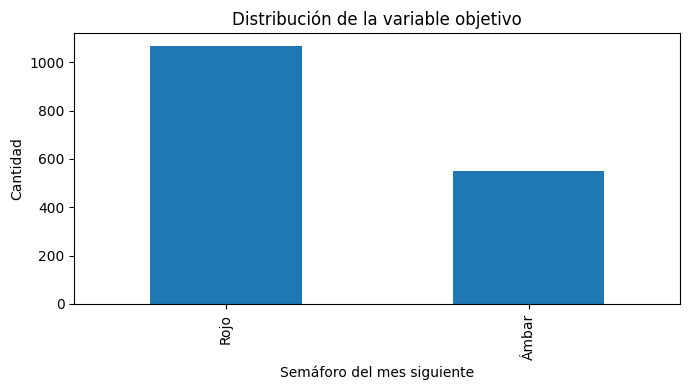

In [4]:
target = "semaforo_mes_siguiente"

if target not in df.columns:
    raise ValueError(
        f"No existe la columna target '{target}'. Columnas disponibles: {list(df.columns)}"
    )

# Quitar registros sin target: el último mes de cada asesor normalmente no tiene mes siguiente.
df_model = df.copy()
df_model[target] = df_model[target].astype(str).str.strip()

valores_invalidos = ["", "nan", "none", "null", "sin dato", "no aplica", "na"]
df_model = df_model[~df_model[target].str.lower().isin(valores_invalidos)].copy()

print("Filas para modelado:", df_model.shape[0])
print("Distribución del target:")
display(df_model[target].value_counts(dropna=False).to_frame("cantidad"))

plt.figure(figsize=(7, 4))
df_model[target].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Semáforo del mes siguiente")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

## 3. Preparación de variables

In [5]:
# Columnas equivalentes posibles según cambios de nombres entre versiones
alias_columnas = {
    "tipificacion_crm_pct": ["tipificacion_crm_pct", "tip_pct"],
    "horas_conexion_pct": ["horas_conexion_pct", "cumplimiento_pct", "cumplimiento_horas_pct"],
    "tmo_pct": ["tmo_pct", "nc_tmo", "cumplimiento_tmo_pct"],
}

def resolver_columna(nombre_preferido):
    if nombre_preferido in df_model.columns:
        return nombre_preferido
    for candidato in alias_columnas.get(nombre_preferido, []):
        if candidato in df_model.columns:
            return candidato
    return None

# Variables candidatas del modelo operativo.
features_candidatas = [
    "aprobacion_inmediata_pct",
    "horas_conexion_pct",
    "tmo_minutos",
    "tmo_pct",
    "nps_pct",
    "calidad_pct",
    "tipificacion_crm_pct",
    "nc_aprobacion",
    "nc_horas_conexion",
    "nc_tmo",
    "nc_nps",
    "nc_calidad",
    "nc_tipificacion"
]

features_resueltas = []
renombres_usados = {}

for col in features_candidatas:
    col_real = resolver_columna(col)
    if col_real is not None and col_real not in features_resueltas:
        features_resueltas.append(col_real)
        renombres_usados[col] = col_real

features_finales = features_resueltas

if len(features_finales) == 0:
    raise ValueError("No se encontró ninguna variable predictora válida en el dataset.")

print("Variables encontradas para entrenamiento:")
for f in features_finales:
    print("-", f)

faltantes = [c for c in features_candidatas if resolver_columna(c) is None]
print("\nVariables candidatas no encontradas, se omiten:")
for f in faltantes:
    print("-", f)

Variables encontradas para entrenamiento:
- aprobacion_inmediata_pct
- horas_conexion_pct
- tmo_minutos
- nc_tmo
- nps_pct
- calidad_pct
- tipificacion_crm_pct
- nc_aprobacion
- nc_horas_conexion
- nc_nps
- nc_calidad
- nc_tipificacion

Variables candidatas no encontradas, se omiten:


## 4. Limpieza técnica para modelado

In [6]:
# Copia de modelado
model_data = df_model[features_finales + [target]].copy()

# Conversión robusta de posibles numéricos almacenados como texto
for col in features_finales:
    if model_data[col].dtype == "object":
        serie_limpia = (
            model_data[col].astype(str)
            .str.replace("%", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )
        convertido = pd.to_numeric(serie_limpia, errors="coerce")
        # Si al menos 70% de los valores no nulos se convierten a número, tratar como numérico
        ratio_convertido = convertido.notna().mean()
        if ratio_convertido >= 0.70:
            model_data[col] = convertido

# Eliminar filas sin target y controlar nulos
model_data = model_data.dropna(subset=[target]).copy()

X = model_data[features_finales].copy()
y = model_data[target].copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

for col in numeric_features:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_features:
    X[col] = X[col].astype(str).replace({"nan": "Sin dato", "None": "Sin dato"}).fillna("Sin dato")

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)
print("Clases:", sorted(y.unique()))

Features numéricas: ['aprobacion_inmediata_pct', 'horas_conexion_pct', 'tmo_minutos', 'nc_tmo', 'nps_pct', 'calidad_pct', 'tipificacion_crm_pct', 'nc_aprobacion', 'nc_horas_conexion', 'nc_nps', 'nc_calidad', 'nc_tipificacion']
Features categóricas: []
Clases: ['Rojo', 'Ámbar']


## 5. Función de entrenamiento y evaluación

In [7]:
def construir_preprocessor(categorical_features, numeric_features):
    transformers = []

    if len(categorical_features) > 0:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        )

    if len(numeric_features) > 0:
        transformers.append(
            ("num", StandardScaler(), numeric_features)
        )

    return ColumnTransformer(transformers=transformers)


def dividir_train_test(X, y):
    # Stratify solo si cada clase tiene al menos 2 registros
    conteo_clases = y.value_counts()
    usar_stratify = conteo_clases.min() >= 2 and y.nunique() > 1

    return train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y if usar_stratify else None
    )


def entrenar_y_evaluar_modelos(X, y, features, nombre_version):
    numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]

    preprocessor = construir_preprocessor(categorical_features, numeric_features)

    X_train, X_test, y_train, y_test = dividir_train_test(X, y)

    models = {
        "Regresión logística": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ),
        "Árbol de decisión": DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        )
    }

    resultados = []
    modelos_entrenados = {}
    predicciones = {}

    for name, model in models.items():
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="weighted", zero_division=0
        )

        resultados.append({
            "version": nombre_version,
            "modelo": name,
            "accuracy": accuracy,
            "precision_weighted": precision,
            "recall_weighted": recall,
            "f1_weighted": f1
        })

        modelos_entrenados[name] = pipeline
        predicciones[name] = y_pred

    df_results = pd.DataFrame(resultados).sort_values("accuracy", ascending=False)

    return {
        "df_results": df_results,
        "models": modelos_entrenados,
        "predicciones": predicciones,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "features": features,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features
    }

## 6. Entrenamiento de modelos

In [8]:
resultado_modelo = entrenar_y_evaluar_modelos(
    X=X,
    y=y,
    features=features_finales,
    nombre_version="Modelo operativo actualizado"
)

comparacion_final = resultado_modelo["df_results"]
display(comparacion_final)

,version,modelo,accuracy,precision_weighted,recall_weighted,f1_weighted
2,Modelo operativo actualizado,Random Forest,0.762963,0.767674,0.762963,0.764845
1,Modelo operativo actualizado,Árbol de decisión,0.676543,0.785053,0.676543,0.681199
0,Modelo operativo actualizado,Regresión logística,0.607407,0.689109,0.607407,0.615485


## 7. Selección del modelo final

Se selecciona **Random Forest** como modelo final, porque en la comparación de métricas presenta mejor desempeño predictivo.

La Regresión Logística queda como modelo base de comparación por su interpretabilidad, pero la decisión final prioriza la capacidad de clasificación del semáforo.

In [9]:
# Modelo final seleccionado por decisión técnica del proyecto
# Motivo: mejor desempeño predictivo frente a Regresión Logística y Árbol de Decisión.
modelo_final_nombre = "Random Forest"

if modelo_final_nombre not in resultado_modelo["models"]:
    raise ValueError(f"No se encontró el modelo seleccionado: {modelo_final_nombre}")

modelo_final = resultado_modelo["models"][modelo_final_nombre]

y_test_final = resultado_modelo["y_test"]
X_test_final = resultado_modelo["X_test"]
y_pred_final = resultado_modelo["predicciones"][modelo_final_nombre]

accuracy_final = accuracy_score(y_test_final, y_pred_final)
precision_final, recall_final, f1_final, _ = precision_recall_fscore_support(
    y_test_final, y_pred_final, average="weighted", zero_division=0
)

print("Modelo final seleccionado:", modelo_final_nombre)
print("Criterio de selección: mejor desempeño predictivo en la comparación de modelos")
print("Accuracy final:", round(accuracy_final, 4))
print("Precision weighted:", round(precision_final, 4))
print("Recall weighted:", round(recall_final, 4))
print("F1 weighted:", round(f1_final, 4))
print("Variables finales:", features_finales)

Modelo final seleccionado: Random Forest
Criterio de selección: mejor desempeño predictivo en la comparación de modelos
Accuracy final: 0.763
Precision weighted: 0.7677
Recall weighted: 0.763
F1 weighted: 0.7648
Variables finales: ['aprobacion_inmediata_pct', 'horas_conexion_pct', 'tmo_minutos', 'nc_tmo', 'nps_pct', 'calidad_pct', 'tipificacion_crm_pct', 'nc_aprobacion', 'nc_horas_conexion', 'nc_nps', 'nc_calidad', 'nc_tipificacion']


## 8. Matriz de confusión y reporte de clasificación

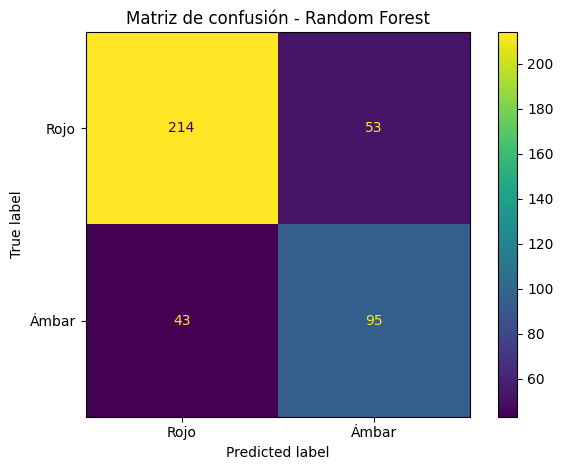

              precision    recall  f1-score   support

        Rojo       0.83      0.80      0.82       267
       Ámbar       0.64      0.69      0.66       138

    accuracy                           0.76       405
   macro avg       0.74      0.74      0.74       405
weighted avg       0.77      0.76      0.76       405



In [10]:
labels_ordenados = list(modelo_final.classes_)

cm = confusion_matrix(
    y_test_final,
    y_pred_final,
    labels=labels_ordenados
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_ordenados
)

disp.plot()
plt.title(f"Matriz de confusión - {modelo_final_nombre}")
plt.tight_layout()
plt.show()

print(classification_report(y_test_final, y_pred_final, zero_division=0))

## 9. Importancia de variables

,variable,importancia
4,nps_pct,0.200580
9,nc_nps,0.183850
1,horas_conexion_pct,0.110930
8,nc_horas_conexion,0.086370
5,calidad_pct,0.071786
11,nc_tipificacion,0.070915
10,nc_calidad,0.070513
2,tmo_minutos,0.068462
6,tipificacion_crm_pct,0.067895
3,nc_tmo,0.040161


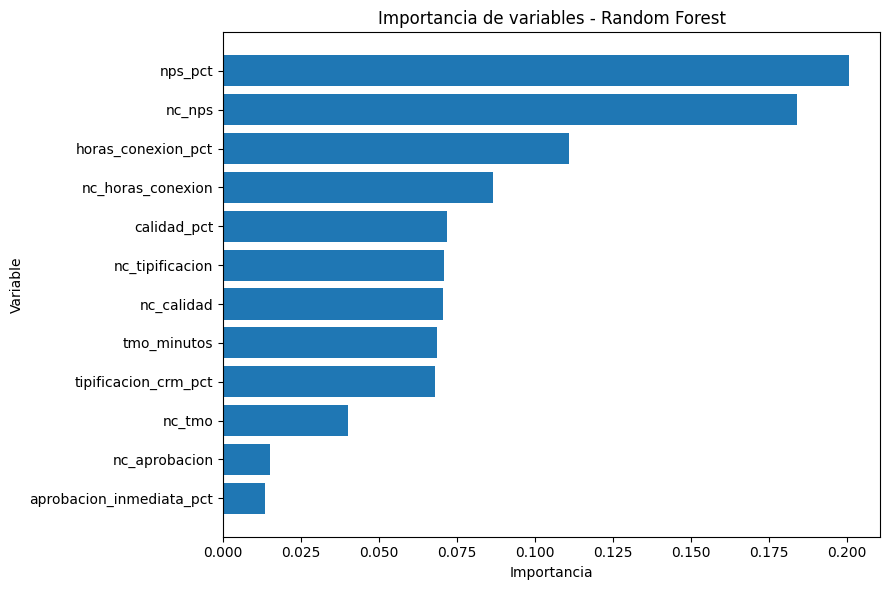

In [11]:
def obtener_feature_names(preprocessor, categorical_features, numeric_features):
    feature_names = []

    if len(categorical_features) > 0 and "cat" in preprocessor.named_transformers_:
        cat_encoder = preprocessor.named_transformers_["cat"]
        cat_names = cat_encoder.get_feature_names_out(categorical_features)
        feature_names.extend(list(cat_names))

    if len(numeric_features) > 0:
        feature_names.extend(numeric_features)

    return feature_names


modelo_interno = modelo_final.named_steps["model"]
preprocessor = modelo_final.named_steps["preprocessor"]

feature_names = obtener_feature_names(
    preprocessor,
    resultado_modelo["categorical_features"],
    resultado_modelo["numeric_features"]
)

if hasattr(modelo_interno, "coef_"):
    coef_abs = np.abs(modelo_interno.coef_).mean(axis=0)
    df_importance_final = pd.DataFrame({
        "variable": feature_names,
        "importancia": coef_abs
    }).sort_values("importancia", ascending=False)
elif hasattr(modelo_interno, "feature_importances_"):
    df_importance_final = pd.DataFrame({
        "variable": feature_names,
        "importancia": modelo_interno.feature_importances_
    }).sort_values("importancia", ascending=False)
else:
    df_importance_final = pd.DataFrame(columns=["variable", "importancia"])

display(df_importance_final.head(20))

if not df_importance_final.empty:
    plt.figure(figsize=(9, 6))
    plt.barh(
        df_importance_final.head(15)["variable"][::-1],
        df_importance_final.head(15)["importancia"][::-1]
    )
    plt.title(f"Importancia de variables - {modelo_final_nombre}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

## 10. Guardar modelo, metadata y resultados

In [12]:
model_path = MODELS_DIR / "modelo_semaforo.pkl"
metadata_path = MODELS_DIR / "metadata_modelo_semaforo.pkl"

joblib.dump(modelo_final, model_path)

metadata = {
    "version_modelo": "Modelo operativo actualizado - Random Forest",
    "algoritmo": modelo_final_nombre,
    "criterio_seleccion": "Se selecciona Random Forest por presentar mejores indicadores de desempeño predictivo en la comparación de modelos.",
    "features": features_finales,
    "target": target,
    "classes": list(modelo_final.classes_),
    "accuracy": float(accuracy_final),
    "precision_weighted": float(precision_final),
    "recall_weighted": float(recall_final),
    "f1_weighted": float(f1_final),
    "numeric_features": resultado_modelo["numeric_features"],
    "categorical_features": resultado_modelo["categorical_features"]
}

joblib.dump(metadata, metadata_path)

comparacion_path = DATA_DIR / "comparacion_modelos.csv"
importancia_path = DATA_DIR / "importancia_variables_modelo_final.csv"

comparacion_final.to_csv(comparacion_path, index=False, encoding="utf-8-sig")
df_importance_final.to_csv(importancia_path, index=False, encoding="utf-8-sig")

print("Modelo guardado en:", model_path)
print("Metadata guardada en:", metadata_path)
print("Comparación guardada en:", comparacion_path)
print("Importancia de variables guardada en:", importancia_path)

Modelo guardado en: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\models\modelo_semaforo.pkl
Metadata guardada en: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\models\metadata_modelo_semaforo.pkl
Comparación guardada en: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\data\processed\comparacion_modelos.csv
Importancia de variables guardada en: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\data\processed\importancia_variables_modelo_final.csv


## 11. Prueba rápida de carga y predicción

In [15]:
modelo_cargado = joblib.load(model_path)
metadata_cargada = joblib.load(metadata_path)

print("Modelo cargado correctamente")
print("Algoritmo:", metadata_cargada["algoritmo"])
print("Clases:", metadata_cargada["classes"])
print("Variables:", metadata_cargada["features"])

ejemplo = X_test_final.iloc[[0]].copy()
print(ejemplo)
prediccion = modelo_cargado.predict(ejemplo)
probabilidades = modelo_cargado.predict_proba(ejemplo)

print("\nPredicción:", prediccion[0])

display(pd.DataFrame(
    probabilidades,
    columns=modelo_cargado.classes_
))

Modelo cargado correctamente
Algoritmo: Random Forest
Clases: ['Rojo', 'Ámbar']
Variables: ['aprobacion_inmediata_pct', 'horas_conexion_pct', 'tmo_minutos', 'nc_tmo', 'nps_pct', 'calidad_pct', 'tipificacion_crm_pct', 'nc_aprobacion', 'nc_horas_conexion', 'nc_nps', 'nc_calidad', 'nc_tipificacion']
    aprobacion_inmediata_pct  horas_conexion_pct  tmo_minutos  nc_tmo  \
18                      55.0           78.997333     6.063889     0.0   

    nps_pct  calidad_pct  tipificacion_crm_pct  nc_aprobacion  \
18    76.96         82.4             84.647059          150.0   

    nc_horas_conexion  nc_nps  nc_calidad  nc_tipificacion  
18                0.0   150.0        62.0            46.47  

Predicción: Rojo


,Rojo,Ámbar
0,0.756704,0.243296
